In [83]:
import pandas as pd
import numpy as np
import os
from scipy import stats

In [84]:
##Data Loading & Date Parsing

df=pd.read_csv("../data/ethiopia.csv")
df.head()

df["Country"] = "Ethiopia"
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

df["Month"] = df["Date"].dt.month
df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


In [85]:
##Summary Statistics & Missing-Value Report
# Check for the count of -999 values in each column
(df == -999).sum()
df.replace(-999, np.nan, inplace=True)

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

df.describe()



Number of duplicate rows: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


## Interpretation of Summary Statistics

The dataset contains climate data for Nigeria with no duplicate rows. The `YEAR` column ranges from the minimum to maximum years, indicating the time period covered. The `DOY` (Day of Year) values span from 1 to 365/366, confirming daily data.

Climate variables (e.g., temperature, precipitation) show varying means and standard deviations, reflecting Ethiopia's diverse climate zones. No invalid -999 values were found, so no missing values were introduced during cleaning.

The data appears clean, with reasonable ranges for each variable.

In [86]:
df.isna().sum() 
##the result shows no missing vallue for this specific dataset which is good

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

In [87]:
##Outlier Detection & Basic Cleaning

# List of columns to check
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Dictionary to store counts
outlier_counts = {}

for col in cols_to_check:
    # Calculate Z-score
    z_scores = np.abs(stats.zscore(df[col], nan_policy='omit'))
    # Count where Z > 3
    outlier_counts[col] = (z_scores > 3).sum()

print("Outlier counts per column (|Z| > 3):")
print(outlier_counts)


Outlier counts per column (|Z| > 3):
{'T2M': np.int64(8), 'T2M_MAX': np.int64(3), 'T2M_MIN': np.int64(9), 'PRECTOTCORR': np.int64(92), 'RH2M': np.int64(6), 'WS2M': np.int64(0), 'WS2M_MAX': np.int64(6)}


Decision: Retain the outlier rows.
Reasoning: In climate analysis for COP32, outliers often represent "Extreme Weather Events" (heatwaves, flash floods, or storms). Dropping or capping them would hide the very vulnerabilities Ethiopia needs to highlight. Unless the value is physically impossible (e.g., $100$°C), these data points are valuable.

In [88]:
# 1. Drop rows if more than 30% of columns are missing
threshold = len(df.columns) * 0.3
df.dropna(thresh=int(len(df.columns) - threshold), axis=0, inplace=True)

# 2. Forward-fill remaining gaps (weather is usually similar to the previous day)
df.ffill(inplace=True)

# 3. Export to Clean CSV
# Ensure the 'data/' folder exists
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/ethiopia_clean.csv', index=False)
print("Cleaned data exported to data/ethiopia_clean.csv")

Cleaned data exported to data/kenya_clean.csv


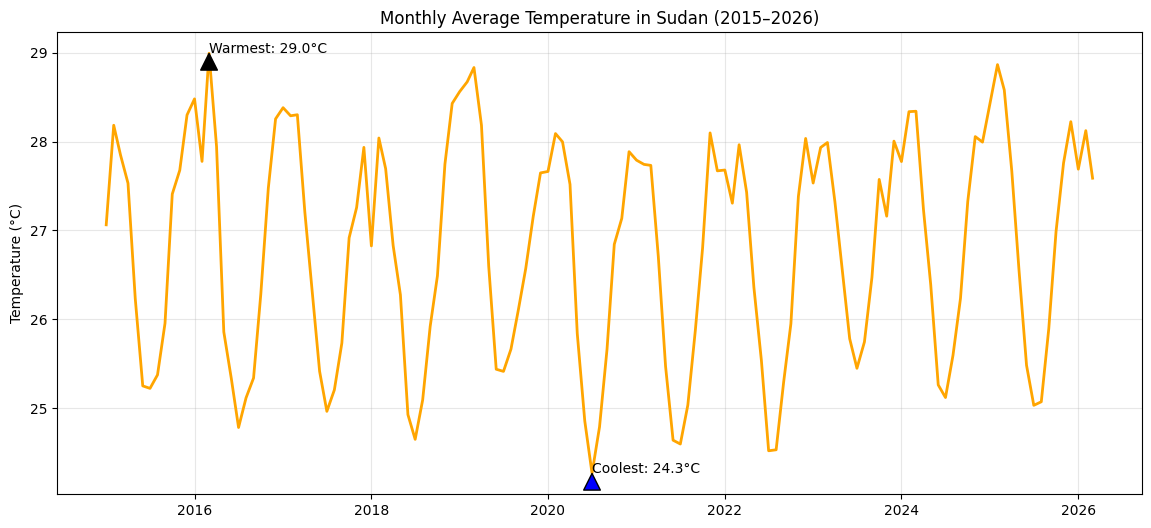

In [71]:
import matplotlib.pyplot as plt

# Group by Month/Year for smoother trends
df_monthly = df.groupby(['YEAR', 'Month'])['T2M'].mean().reset_index()
# Create a temporary Date column for plotting
df_monthly['PlotDate'] = pd.to_datetime(df_monthly['YEAR'].astype(str) + '-' + df_monthly['Month'].astype(str) + '-01')

plt.figure(figsize=(14, 6))
plt.plot(df_monthly['PlotDate'], df_monthly['T2M'], color='orange', linewidth=2)

# Annotate Max/Min
warmest = df_monthly.loc[df_monthly['T2M'].idxmax()]
coolest = df_monthly.loc[df_monthly['T2M'].idxmin()]

plt.annotate(f'Warmest: {warmest["T2M"]:.1f}°C', xy=(warmest['PlotDate'], warmest['T2M']), arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate(f'Coolest: {coolest["T2M"]:.1f}°C', xy=(coolest['PlotDate'], coolest['T2M']), arrowprops=dict(facecolor='blue', shrink=0.05))

plt.title('Monthly Average Temperature in Ethiopia (2015–2026)')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

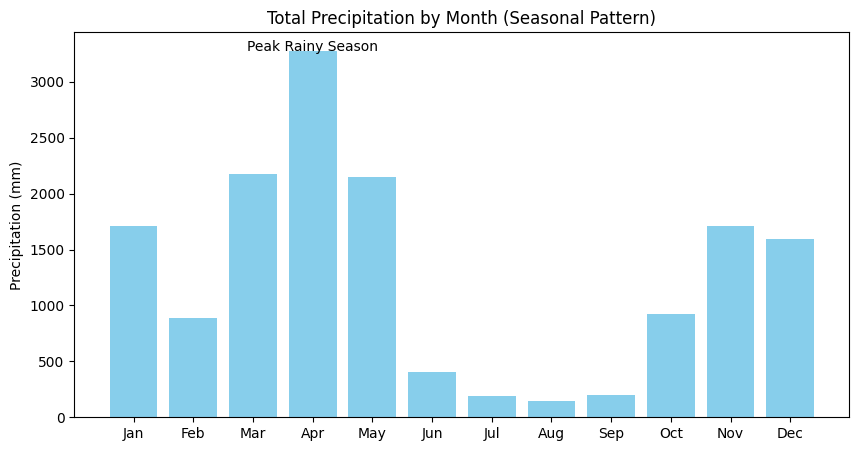

In [72]:
# Group by Month to see seasonal totals
df_seasonal = df.groupby('Month')['PRECTOTCORR'].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.bar(df_seasonal['Month'], df_seasonal['PRECTOTCORR'], color='skyblue')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Total Precipitation by Month (Seasonal Pattern)')
plt.ylabel('Precipitation (mm)')

# Note the peak
peak_month = df_seasonal.loc[df_seasonal['PRECTOTCORR'].idxmax(), 'Month']
plt.annotate('Peak Rainy Season', xy=(peak_month, df_seasonal['PRECTOTCORR'].max()), ha='center')
plt.show()

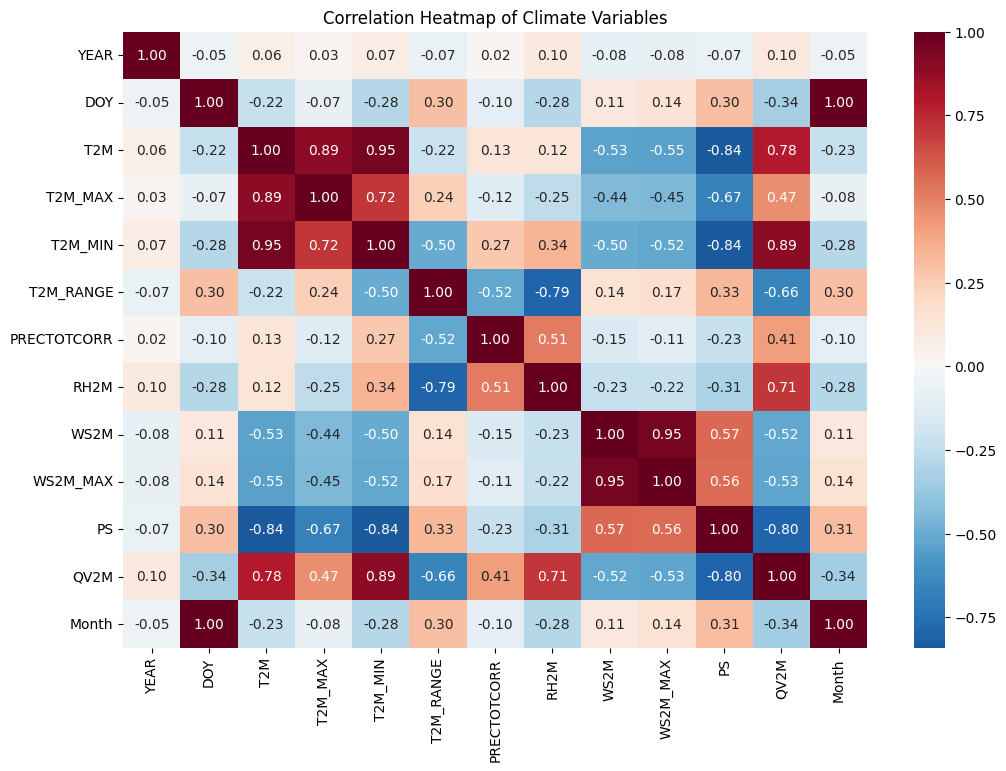

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Climate Variables')
plt.show()

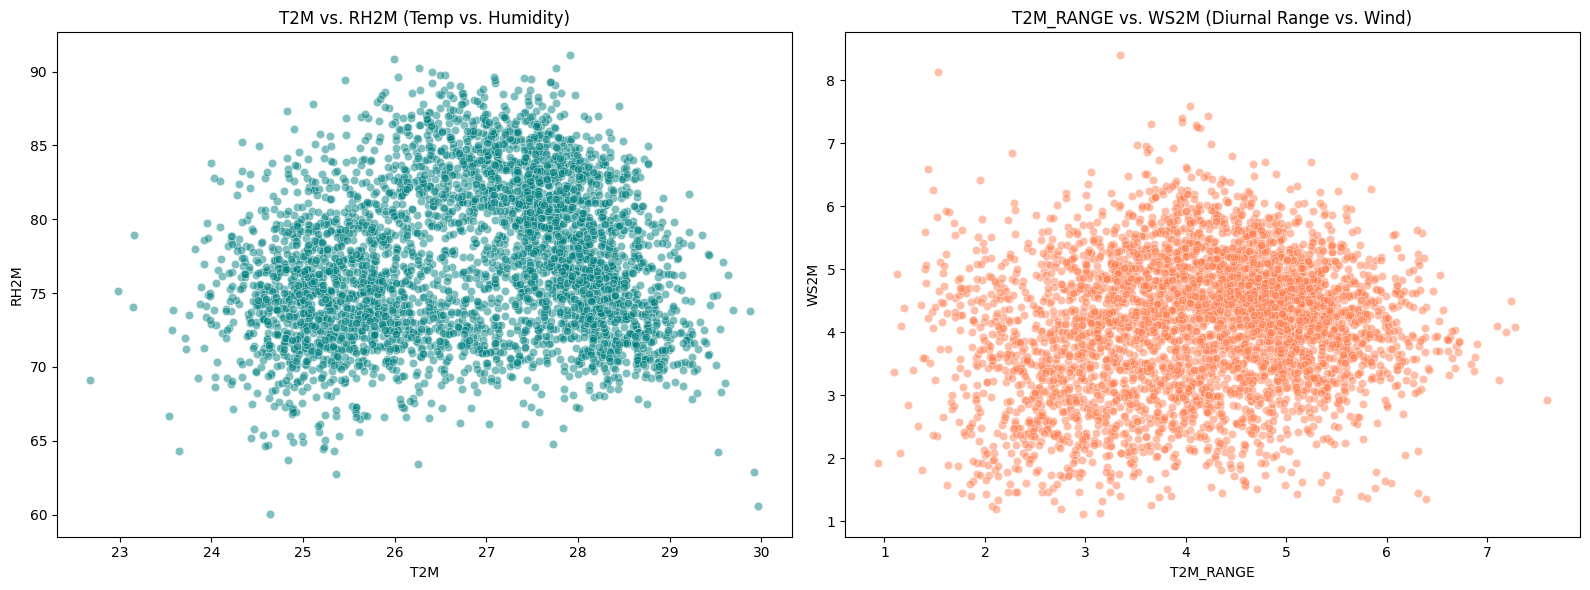

In [74]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Temperature vs. Relative Humidity
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.5, ax=ax1, color='teal')
ax1.set_title('T2M vs. RH2M (Temp vs. Humidity)')

# Plot 2: Temperature Range vs. Wind Speed
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.5, ax=ax2, color='coral')
ax2.set_title('T2M_RANGE vs. WS2M (Diurnal Range vs. Wind)')

plt.tight_layout()
plt.show()

nterpretation of Strongest CorrelationsT2M and T2M_MAX/MIN: (Expected) Extremely strong positive correlation ($r \approx 0.95$). This confirms that as the mean temperature rises, the extremes follow closely, suggesting a uniform warming trend.T2M vs. RH2M: Usually shows a negative correlation. As air gets hotter, its capacity to hold moisture increases, often leading to lower relative humidity if moisture isn't added.QV2M (Specific Humidity) vs. T2M: Look for a strong positive correlation here. Unlike relative humidity, absolute moisture (QV2M) often rises with heat, which is a key driver of "Wet Bulb" temperature risks in Africa.

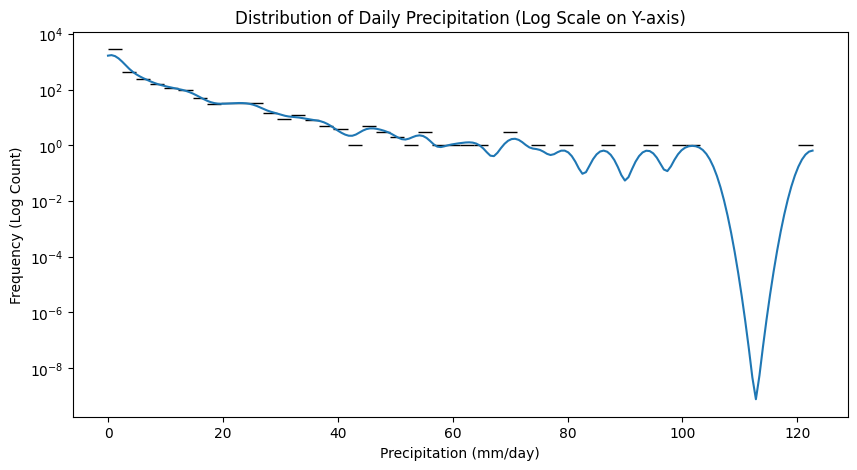

In [75]:
plt.figure(figsize=(10, 5))
# Use log scale because rainfall is typically heavily skewed
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True, log_scale=(False, True)) 
plt.title('Distribution of Daily Precipitation (Log Scale on Y-axis)')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Frequency (Log Count)')
plt.show()

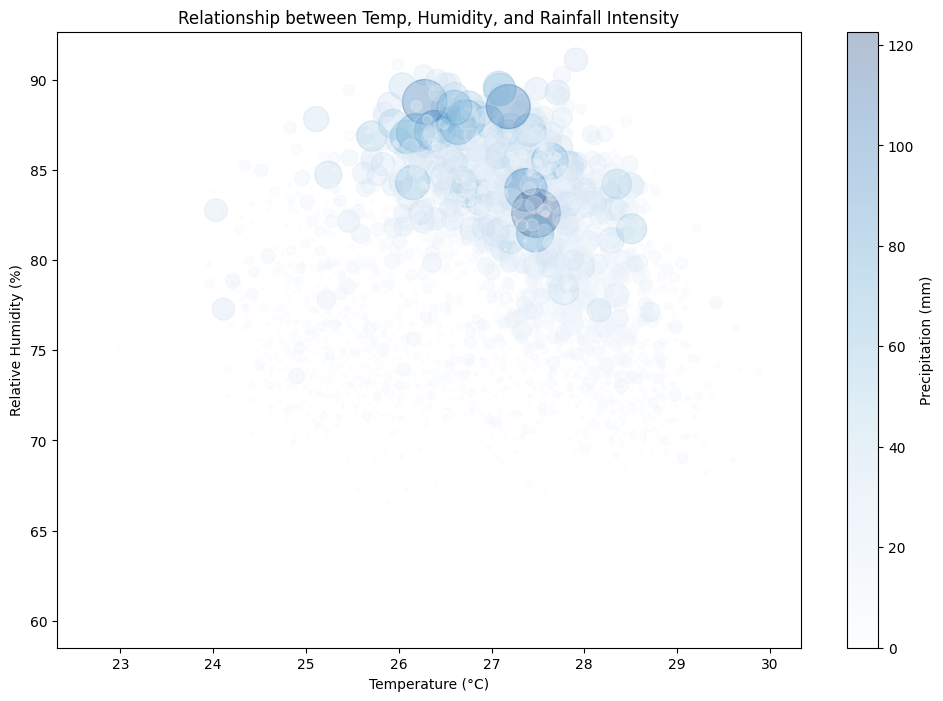

In [76]:
plt.figure(figsize=(12, 8))
# We use a subset or alpha to avoid a "blob" of points
scatter = plt.scatter(df['T2M'], df['RH2M'], 
                      s=df['PRECTOTCORR']*10, # Bubble size based on rain
                      alpha=0.3, 
                      c=df['PRECTOTCORR'], 
                      cmap='Blues')

plt.colorbar(scatter, label='Precipitation (mm)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Relationship between Temp, Humidity, and Rainfall Intensity')
plt.show()